# Community Detection

### Import libraries

In [38]:
import math
import numpy as np
import pandas as pd
import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import time
import dimod
from networkx.algorithms.community.quality import modularity as nx_modularity
from dwave.system import LeapHybridSampler
from dwave.system import DWaveSampler, EmbeddingComposite
from dwave.system import FixedEmbeddingComposite
from dwave.system import LeapHybridDQMSampler
from dwave.samplers import SimulatedAnnealingSampler
from dwave.embedding import embed_bqm
from dwave.embedding.chain_strength import uniform_torque_compensation
from minorminer import find_embedding
from dimod import ExactSolver

# To extract, save, and reuse embedding
import json
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

### Load data

In [56]:
# Load preprocessed network
# 12 --> correlation threshold = 0.12
G = nx.read_graphml('neuronal_graphs/planes_merged_neurons12.graphml')
G.remove_nodes_from(list(nx.isolates(G)))

print(f"Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Graph type: {type(G)}")
print(f"Is directed: {G.is_directed()}")

Graph loaded: 1085 nodes, 3234 edges
Graph type: <class 'networkx.classes.digraph.DiGraph'>
Is directed: True


# 1 Graph preprocessing

### 1.1 Conversion to adjacency matrix

In [128]:
# Convert directed graph to undirected
G_undirected = G.to_undirected()

# Remove any remaining self-loops
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

# Create unweighted adjacency matrix
A = nx.adjacency_matrix(G_undirected, weight=None).toarray()
N = G_undirected.number_of_nodes()
M = G_undirected.number_of_edges()  # Total number of edges

print(f"\nUndirected graph: {N} nodes, {M} edges")
print(f"Adjacency matrix shape: {A.shape}")
print(f"Sparsity: {(A == 0).sum() / A.size * 100:.2f}% zeros")
print(f"\nDegree statistics:")
degrees = [G_undirected.degree(n) for n in G_undirected.nodes()]
print(f"  Min: {min(degrees)}, Max: {max(degrees)}, Mean: {np.mean(degrees):.2f}")


Undirected graph: 1085 nodes, 1617 edges
Adjacency matrix shape: (1085, 1085)
Sparsity: 99.73% zeros

Degree statistics:
  Min: 1, Max: 10, Mean: 2.98


In [ ]:
# def hbgib_community_prune(G, retain_ratio=0.7):
#     """
#     Community-aware graph pruning based on the Hierarchical Brain Graph Information Bottleneck framework,
#     widely used in network neuroscience for brain network dimensionality reduction.
#     """
#     G_pruned = G.copy()

#     initial_communities = list(nx.algorithms.community.louvain_communities(G_pruned))
#     removed_nodes = set()

#     # processes each community independently
#     for comm_nodes in initial_communities:
#         subgraph = G_pruned.subgraph(comm_nodes)
#         comm_size = len(comm_nodes)
#         # calculate node-level information bottleneck score for each node in the community
#         node_scores = {}
#         for n in subgraph.nodes():
#             clust = nx.clustering(subgraph, n)
#             betw = nx.betweenness_centrality(subgraph, normalized=True)[n]
#             node_scores[n] = clust * (1 - betw)
#         # sort nodes by score
#         sorted_nodes = sorted(node_scores.items(), key=lambda x: x[1])
#         nodes_to_remove = sorted_nodes[:int(comm_size * (1 - retain_ratio))]
#         for n, _ in nodes_to_remove:
#             neighbors = list(G_pruned.neighbors(n))
#             if len(neighbors) >= 2:
#                 u, v = neighbors[0], neighbors[-1]
#                 if not G_pruned.has_edge(u, v):
#                     G_pruned.add_edge(u, v)
#             G_pruned.remove_node(n)
#             removed_nodes.add(n)

#     # generate updated adjacency matrix and node index mapping
#     pruned_nodes = list(G_pruned.nodes())
#     node_index_map = {old_idx: new_idx for new_idx, old_idx in enumerate(pruned_nodes)}
#     A_pruned = nx.adjacency_matrix(G_pruned, weight=None).toarray()

#     # statistics
#     N_old = G.number_of_nodes()
#     N_new = G_pruned.number_of_nodes()
#     print(f"Pruned graph: {N_new} nodes (removed {N_old - N_new} nodes), {G_pruned.number_of_edges()} edges")
#     print(f"Sparsity: {(A_pruned == 0).sum() / A_pruned.size * 100:.2f}% zeros")
#     print(f"New adjacency matrix shape: {A_pruned.shape}")
#     return G_pruned, A_pruned, node_index_map, removed_nodes

# G_pruned, A_pruned, node_index_map, removed_nodes = hbgib_community_prune(G_undirected)
# G_undirected = G_pruned
# A = A_pruned

Pruned graph: 897 nodes (removed 188 nodes), 1214 edges
Sparsity: 99.70% zeros
New adjacency matrix shape: (897, 897)


In [129]:
def communities_to_partition(communities):
    """
    Convert a list of community sets to a partition array.
    Returns: array where partition[i] = community_id for node i
    """
    node_list = list(G_undirected.nodes())  # Use the current graph's node order
    node_to_idx = {node: idx for idx, node in enumerate(node_list)}
    partition = np.zeros(len(node_list), dtype=int)
    for community_id, community_set in enumerate(communities):
        for node in community_set:
            partition[node_to_idx[node]] = community_id
    return partition

def compute_modularity(partition, A):
    """
    Compute modularity Q for a given partition.
    Q = (1/2m) * sum_ij (A_ij - k_i*k_j/2m) * delta(c_i, c_j)
    where k_i is the degree of node i, and delta(c_i, c_j) = 1 if nodes i,j in same community
    """
    n = A.shape[0]

    degrees = A.sum(axis=1)
    m = A.sum() / 2.0  # total edges (double counted in adjacency matrix)
    
    Q = 0.0
    for i in range(n):
        for j in range(n):
            if partition[i] == partition[j]:
                Q += A[i, j] - (degrees[i] * degrees[j]) / (2.0 * m)
    
    Q /= (2.0 * m)
    return Q

def compute_conductance(partition, A):
    degrees = A.sum(axis=1)
    conductances = []
    for community_id in np.unique(partition):
        S  = np.where(partition == community_id)[0]
        if len(S) <= 1:
            continue
        Sc = np.where(partition != community_id)[0]
        if len(Sc) == 0:
            continue
        cut   = A[np.ix_(S, Sc)].sum()
        vol_S = degrees[S].sum()
        vol_c = degrees[Sc].sum()
        denom = min(vol_S, vol_c)
        if denom > 0:
            conductances.append(cut / denom)
    singleton_count = 0
    double_count = 0
    for community_id in np.unique(partition):
        S = np.where(partition == community_id)[0]
        if len(S) == 1:
            singleton_count += 1  # Max conductance for single-node communities
        if len(S) == 2:
            double_count += 1  # Max conductance for two-node communities
            
    penalty = (singleton_count/(len(partition)))+(double_count/(len(partition)*2))
    return (np.mean(conductances) + (1-np.mean(conductances))*penalty) if conductances else np.nan


# 2 Classical community detection

In [124]:
def greedy_refinement(A, partition):
    """
    Refines the partition using a greedy local search.
    Moves each node to the community that gives the highest modularity increase.
    """
    refined_partition = partition.copy()
    N = A.shape[0]
    unique_communities = np.unique(partition)
    improved = True
    
    current_modularity = compute_modularity(refined_partition, A)
    
    print(f"Starting refinement... Initial Modularity: {current_modularity:.6f}")
    
    while improved:
        improved = False
        nodes = np.random.permutation(N)
        
        for i in nodes:
            best_move = refined_partition[i]
            initial_comm = refined_partition[i]
            for target_comm in unique_communities:
                if target_comm == initial_comm:
                    continue
                refined_partition[i] = target_comm
                new_modularity = compute_modularity(refined_partition, A)
                if new_modularity > current_modularity:
                    current_modularity = new_modularity
                    best_move = target_comm
                    improved = True
            refined_partition[i] = best_move
            
    print(f"Refinement complete. Optimized Modularity: {current_modularity:.6f}")
    return refined_partition


### 2.1 Louvain

Tuning resolution parameter for Louvain

  Max Modularity: 0.586653
  Number of Communities: 266
  Conductance: 0.539883


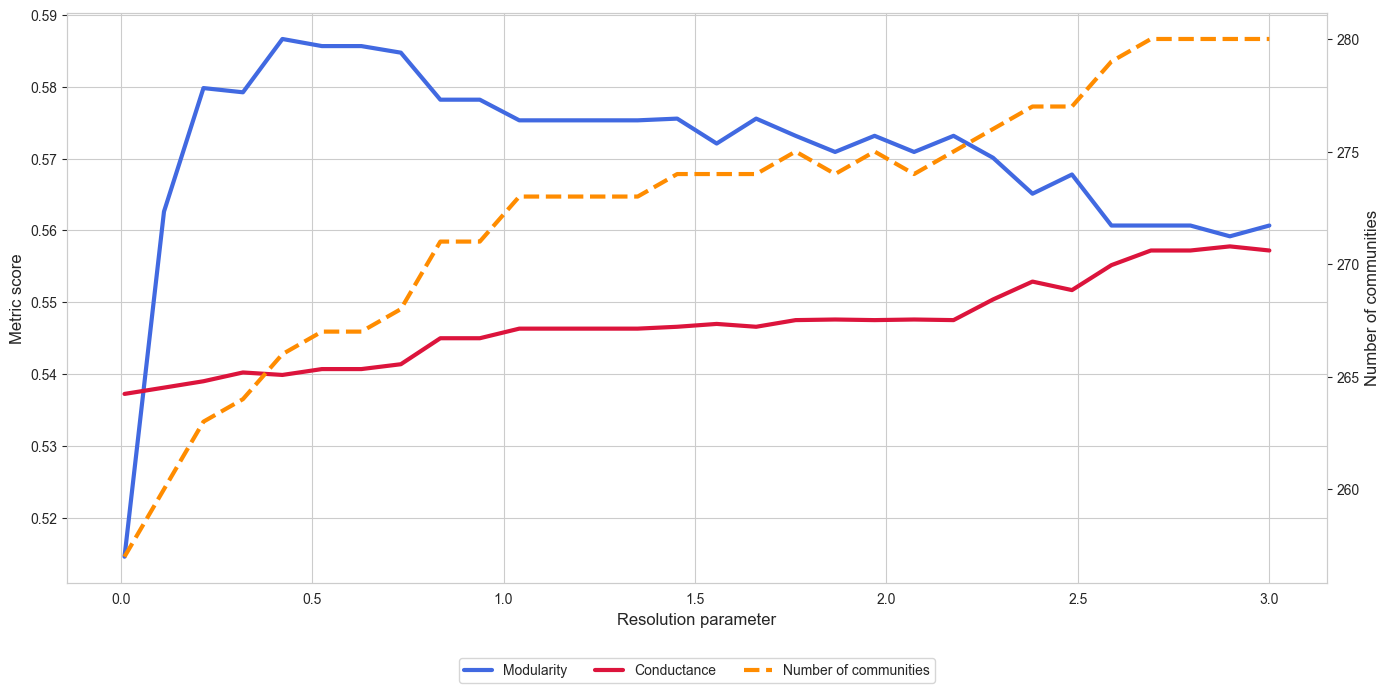

In [117]:
resolution_range = np.linspace(0.01, 3.0, 30)
tuning_results = []
for res in resolution_range:
    start_time = time.time()
    # run Louvain with specified resolution
    communities_louvain = list(nx.community.louvain_communities(G_undirected, seed=42, resolution=res))
    runtime = time.time() - start_time
    
    # calculate/post process
    partition_louvain = communities_to_partition(communities_louvain)
    modularity_louvain = compute_modularity(partition_louvain, A)
    conductance_louvain = compute_conductance(partition_louvain, A)
    
    tuning_results.append({
        'resolution': res,
        'num_communities': len(communities_louvain),
        'modularity': modularity_louvain,
        'conductance': conductance_louvain,
        'runtime': runtime
    })

df_tuning = pd.DataFrame(tuning_results)

best_mod_row = df_tuning.loc[df_tuning['modularity'].idxmax()]

print(f"  Max Modularity: {best_mod_row['modularity']:.6f}")
print(f"  Number of Communities: {int(best_mod_row['num_communities'])}")
print(f"  Conductance: {best_mod_row['conductance']:.6f}")

fig, ax1 = plt.subplots(figsize=(14, 7))

sns.lineplot(data=df_tuning, x='resolution', y='modularity', ax=ax1, label='Modularity', color='royalblue',linewidth=3)
sns.lineplot(data=df_tuning, x='resolution', y='conductance', ax=ax1, label='Conductance', color='crimson', linewidth=3)
ax1.set_ylabel('Metric score', fontsize=12)
ax1.set_xlabel('Resolution parameter', fontsize=12)

ax2 = ax1.twinx()
sns.lineplot(data=df_tuning, x='resolution', y='num_communities', ax=ax2, label='Number of communities', color='darkorange', linestyle='--', linewidth=3)
ax2.set_ylabel('Number of communities', fontsize=12)
ax2.grid(False) 

# sync legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.get_legend().remove()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=True)

plt.tight_layout()
plt.show()

In [130]:
start_time = time.time()
communities_louvain = list(nx.community.louvain_communities(G_undirected, seed=42))
louvain_runtime = time.time() - start_time

partition_louvain = communities_to_partition(communities_louvain)
modularity_louvain = compute_modularity(partition_louvain, A)
conductance_louvain = compute_conductance(partition_louvain, A)
#partition_louvain_optimized = greedy_refinement(A, partition_louvain)
# modularity_louvain = compute_modularity(partition_louvain_optimized, A)
# conductance_louvain = compute_conductance(partition_louvain_optimized, A)

print(f"Runtime: {louvain_runtime:.4f}s")
print(f"Number of communities: {len(communities_louvain)}")
print(f"Modularity: {modularity_louvain:.6f}")
print(f"Conductance: {conductance_louvain:.6f}")
print(f"Community sizes: {sorted([len(c) for c in communities_louvain], reverse=True)}")
print(f"Number of communities: {len(communities_louvain)}")

Runtime: 0.0555s
Number of communities: 340
Modularity: 0.495494
Conductance: 0.550424
Community sizes: [47, 34, 34, 33, 32, 30, 23, 22, 22, 19, 18, 17, 16, 16, 15, 14, 13, 13, 13, 11, 11, 11, 11, 10, 10, 10, 10, 9, 9, 9, 9, 9, 9, 9, 9, 7, 7, 7, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

### 2.2 Greedy modularity optimization

In [131]:
start_time = time.time()
communities_greedy = list(nx.community.greedy_modularity_communities(G_undirected))
greedy_runtime = time.time() - start_time

#no need for optimization because it accomplishes the same (greedy)

partition_greedy = communities_to_partition(communities_greedy)
modularity_greedy = compute_modularity(partition_greedy, A)
conductance_greedy = compute_conductance(partition_greedy, A)

print(f"Runtime: {greedy_runtime:.4f}s")
print(f"Number of communities: {len(communities_greedy)}")
print(f"Modularity: {modularity_greedy:.6f}")
print(f"Conductance: {conductance_greedy:.6f}")
print(f"Community sizes: {sorted([len(c) for c in communities_greedy], reverse=True)}")

Runtime: 0.0834s
Number of communities: 50
Modularity: 0.776127
Conductance: 0.107855
Community sizes: [69, 59, 55, 54, 52, 46, 44, 44, 43, 42, 41, 38, 37, 36, 36, 35, 35, 34, 32, 31, 28, 25, 24, 24, 24, 22, 18, 7, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


Eigengap estimate: k = 19 communities
Number of (near-)zero eigenvalues (connected components): 24


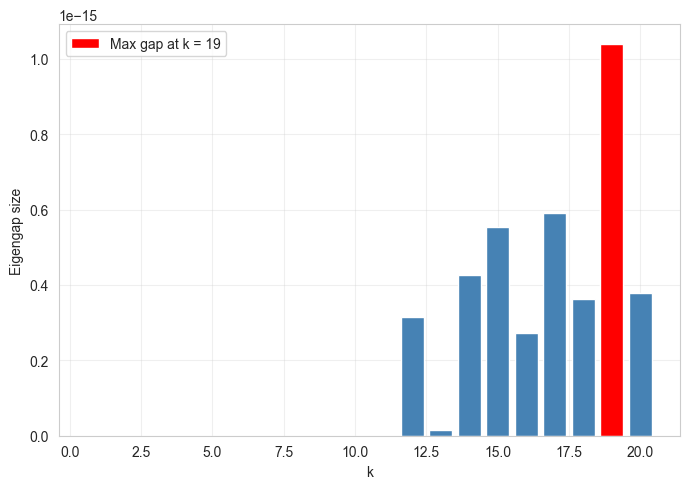

In [132]:

# compute the maximum eigengap to estimate number of communities

def compute_eigengap_estimate(A, max_k=20, plot=True):
    """
    Estimate the number of communities using the eigengap heuristic on the
    unnormalized graph Laplacian L = D - A.
    
    k_estimate: estimated number of communities 
    eigenvalues: full sorted array of eigenvalues
    gaps: array of consecutive eigenvalue differences
    """
    degrees = A.sum(axis=1)
    D = np.diag(degrees)
    L = D - A

    eigenvalues = np.linalg.eigvalsh(L)
    eigenvalues = np.sort(eigenvalues)
    eigenvalues[eigenvalues < 0] = 0

    # Only look for the gap within the first max_k eigenvalues (smallest ones)
    max_k = min(max_k, len(eigenvalues) - 1)
    eigenvalues_subset = eigenvalues[:max_k + 1]
    gaps = np.diff(eigenvalues_subset)
    k_estimate = int(np.argmax(gaps)) + 1
    k_estimate = max(2, k_estimate)  # at least 2 communities

    print(f"Eigengap estimate: k = {k_estimate} communities")

    # Number of (near-)zero eigenvalues = number of connected components
    num_zero_eigenvalues = int(np.sum(eigenvalues < 1e-8))
    print(f"Number of (near-)zero eigenvalues (connected components): {num_zero_eigenvalues}")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(range(1, max_k + 1), gaps, color='steelblue')
    ax.bar(k_estimate, gaps[k_estimate - 1], color='red', label=f'Max gap at k = {k_estimate}')
    ax.set_xlabel('k')
    ax.set_ylabel('Eigengap size')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return k_estimate, eigenvalues, gaps


k_eigengap, laplacian_eigenvalues, eigengaps = compute_eigengap_estimate(A, max_k=20, plot=True)

### 2.3 Greedy w/ best_n

In [133]:
start_time = time.time()
communities_greedy_bestn = list(nx.community.greedy_modularity_communities(G_undirected, best_n=k_eigengap))
greedy_bestn_runtime = time.time() - start_time

partition_greedy_bestn = communities_to_partition(communities_greedy_bestn)
modularity_greedy_bestn = compute_modularity(partition_greedy_bestn, A)
conductance_greedy_bestn = compute_conductance(partition_greedy_bestn, A)

print(f"Runtime: {greedy_bestn_runtime:.4f}s")
print(f"Number of communities: {len(communities_greedy_bestn)}")
print(f"Modularity: {modularity_greedy_bestn:.6f}")
print(f"Conductance: {conductance_greedy_bestn:.6f}")
print(f"Community sizes: {sorted([len(c) for c in communities_greedy_bestn], reverse=True)}")

Runtime: 0.0858s
Number of communities: 19
Modularity: 0.025794
Conductance: 0.007373
Community sizes: [1047, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


# 3 QUBO with Modularity

### 3.0 Build QUBO matrix

In [148]:
def build_modularity_qubo(A, num_communities=None, lambda_penalty=None, verbose=False):
    """
    Build QUBO matrix for modularity maximization via binary community assignment.
    Variables: x_{i,c} for i in nodes, c in communities
    Constraint: Each node assigned to exactly one community (handled via penalty)
    
    One-hot encoding:
    - num_binary_vars = N * num_communities
    - x[i*num_communities + c] = 1 if node i in community c
    
    QUBO objective: minimize -Q + lambda * penalty
    
    Parameters:
    -----------
    A : ndarray
        Adjacency matrix
    num_communities : int, optional
        Number of communities (default: sqrt(N))
    lambda_penalty : float, optional
        Penalty weight for one-hot constraint.
        If None, automatically set to 10x the max modularity contribution.
    verbose : bool
        Print diagnostics
    """

    N = A.shape[0]
    if num_communities is None:
        num_communities = max(2, int(np.sqrt(N)))

    n_vars = N * num_communities 
    Q = {}

    degrees = A.sum(axis=1)
    m = A.sum() / 2  # Total edges

    # Modularity term: Q = (1/2m) * sum_{c} sum_{i,j} B_{ij} x_{i,c} x_{j,c}
    # For minimization, use -Q in QUBO objective
    max_B = 0  # Track max modularity contribution for scaling
    
    for c in range(num_communities):
        for i in range(N):
            for j in range(i, N):
                var_i = i * num_communities + c
                var_j = j * num_communities + c
                B_ij = A[i, j] - (degrees[i] * degrees[j]) / (2 * m)
                coeff = -B_ij / (2 * m)
                max_B = max(max_B, abs(coeff))

                if i == j:  # diagonal
                    if var_i not in Q:
                        Q[var_i] = 0.0
                    Q[var_i] += coeff
                else:  # off-diagonal
                    key = (var_i, var_j) if var_i < var_j else (var_j, var_i)
                    if key not in Q:
                        Q[key] = 0.0
                    Q[key] += coeff

    if lambda_penalty is None:
        lambda_penalty = max(1.5 * max_B, 1.0)  # At least 5.0
    
    if verbose:
        print(f"Modularity scale (max |coeff|): {max_B:.6f}")
        print(f"Penalty weight (lambda): {lambda_penalty:.6f}")

    # Constraint penalty: each node in exactly one community
    # Penalty: lambda * (sum_c x_{i,c} - 1)^2
    # Expansion:
    #   (sum_c x_{i,c} - 1)^2 = sum_c x_{i,c}^2 + 2*sum_{c1<c2} x_{i,c1}*x_{i,c2} - 2*sum_c x_{i,c} + 1
    #   = sum_c x_{i,c} + 2*sum_{c1<c2} x_{i,c1}*x_{i,c2} - 2*sum_c x_{i,c} + 1   [since x^2=x for binary]
    #   = -sum_c x_{i,c} + 2*sum_{c1<c2} x_{i,c1}*x_{i,c2} + 1
    
    # Linear coefficient: -lambda per variable
    # Quadratic coefficient: +2*lambda per pair

    const_term = N * lambda_penalty
    
    for i in range(N):
        # Linear terms: -lambda * x_{i,c}
        for c in range(num_communities):
            var_i = i * num_communities + c
            if var_i not in Q:
                Q[var_i] = 0.0
            Q[var_i] += -lambda_penalty

        # Quadratic terms: +2*lambda * x_{i,c1}*x_{i,c2}
        for c1 in range(num_communities):
            for c2 in range(c1 + 1, num_communities):
                var_1 = i * num_communities + c1
                var_2 = i * num_communities + c2
                key = (var_1, var_2) if var_1 < var_2 else (var_2, var_1)
                if key not in Q:
                    Q[key] = 0.0
                Q[key] += 2.0 * lambda_penalty

    Q['__const__'] = const_term
    
    if verbose:
        print(f"Constant term (N*lambda): {const_term:.2f}")
        print(f"Total QUBO terms: {len(Q)-1} + 1 const")  # -1 for const term itself

    return Q, num_communities

In [149]:
print(f"Target number of communities: {k_eigengap}")
print(f"Total QUBO variables: {N * k_eigengap}")

# Build QUBO
print(f"\nBuilding QUBO matrix...")
Q_dict, k_communities = build_modularity_qubo(A, k_eigengap, verbose=True)
print(f"QUBO built with {len(Q_dict)-1} terms")
print(f"Constant term: {Q_dict.get('__const__', 0):.2f}")

Target number of communities: 19
Total QUBO variables: 20615

Building QUBO matrix...
Modularity scale (max |coeff|): 0.000309
Penalty weight (lambda): 1.000000
Constant term (N*lambda): 1085.00
Total QUBO terms: 11379480 + 1 const
QUBO built with 11379480 terms
Constant term: 1085.00


In [142]:
# Convert QUBO to BQM (Binary Quadratic Model) for D-Wave
Q_dict_clean = {}
const_offset = 0

for k, v in Q_dict.items():
    if k == '__const__':
        # Extract constant term for later addition
        const_offset = float(v)
    elif isinstance(k, tuple):
        Q_dict_clean[k] = float(v)
    else:
        node_idx = int(k)
        Q_dict_clean[(node_idx, node_idx)] = float(v)

# Create BQM and add the constant offset
bqm = dimod.BinaryQuadraticModel.from_qubo(Q_dict_clean)

# Add constant term to the BQM's offset
bqm.offset += const_offset

print(f"BQM created: {bqm.num_variables} variables, {len(bqm.quadratic)} interactions")
print(f"BQM offset (constant term): {bqm.offset:.2f}")

BQM created: 20615 variables, 11358865 interactions
BQM offset (constant term): 5425.00


### 3.2 Quantum/hybrid solvers

In [150]:
def extract_communities_from_sample(sample, N, k_communities):
    """
    Extract community assignments from QUBO sample.
    For node i, find c where x_{i,c} = 1
    """
    partition = np.zeros(N, dtype=int)
    
    for i in range(N):
        # Find which community this node is assigned to
        for c in range(k_communities):
            var_idx = i * k_communities + c
            if var_idx in sample and sample[var_idx] == 1:
                partition[i] = c
                break
        else:
            # If no community assigned (constraint violation), assign to community 0
            partition[i] = 0
    
    return partition
count = 1

In [ ]:
start_time = time.time()
sampler = LeapHybridSampler()
sampleset_hybrid = sampler.sample(bqm, time_limit=125)

# target_edgelist = sampler.edgelist
# find_embedding(bqm.quadratic, target_edgelist)

# sampleset_hybrid = hybrid_sampler.sample(bqm, time_limit=1)
hybrid_runtime = time.time() - start_time

best_sample_hybrid = sampleset_hybrid.first.sample
best_energy_hybrid = sampleset_hybrid.first.energy
# use_hybrid = True

In [155]:
print(sampler.solver.name)

hybrid_binary_quadratic_model_version2p


In [156]:
# Refine with greedy optimization
partition_hybrid_raw = extract_communities_from_sample(best_sample_hybrid, N, k_communities)
# print("Applying greedy refinement to hybrid solution...")
# partition_hybrid_optimized = greedy_refinement(A, partition_hybrid_raw)
# partition_hybrid = extract_communities_from_sample(best_sample_hybrid, N, k_communities)

num_communities_found_hybrid = len(np.unique(partition_hybrid_raw))
conductance_hybrid = compute_conductance(partition_hybrid_raw, A)
mod_raw = compute_modularity(partition_hybrid_raw, A)
# mod_opt = compute_modularity(partition_hybrid_optimized, A)

print(f"Runtime: {hybrid_runtime:.4f}s")
print(f"Best energy: {best_energy_hybrid:.6f}")
print(f"Number of communities found: {num_communities_found_hybrid}")
print(f"Original hybrid modularity: {mod_raw:.6f}")
# print(f"Optimized hybrid modularity: {mod_opt:.6f}")
print(f"Conductance: {conductance_hybrid:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_hybrid_raw), reverse=True)}")

Runtime: 40.3981s
Best energy: -0.002971
Number of communities found: 19
Original hybrid modularity: 0.007161
Conductance: 0.940721
Community sizes: [np.int64(72), np.int64(64), np.int64(64), np.int64(63), np.int64(62), np.int64(62), np.int64(61), np.int64(61), np.int64(58), np.int64(57), np.int64(57), np.int64(55), np.int64(54), np.int64(53), np.int64(50), np.int64(49), np.int64(49), np.int64(49), np.int64(45)]


3.2bi D-Wave QPU Sampler (Advantage 2)